In [ ]:
import os
import shutil

os.makedirs("/content/plant_demo/train/healthy", exist_ok=True)
os.makedirs("/content/plant_demo/train/diseased", exist_ok=True)
os.makedirs("/content/plant_demo/test/healthy", exist_ok=True)
os.makedirs("/content/plant_demo/test/diseased", exist_ok=True)

shutil.move("/content/healthy1.jpg", "/content/plant_demo/train/healthy/healthy1.jpg")
shutil.move("/content/healthy2.jpg", "/content/plant_demo/train/healthy/healthy2.jpg")
shutil.move("/content/diseased1.jpg", "/content/plant_demo/train/diseased/diseased1.jpg")
shutil.move("/content/diseased2.jpg", "/content/plant_demo/train/diseased/diseased2.jpg")

shutil.copy("/content/plant_demo/train/healthy/healthy1.jpg", "/content/plant_demo/test/healthy/healthy1.jpg")
shutil.copy("/content/plant_demo/train/diseased/diseased1.jpg", "/content/plant_demo/test/diseased/diseased1.jpg")

print("Folder structure created and images moved  ")


Folder structure created and images moved ✅


In [5]:
import tensorflow as tf
data_dir = "/content/plant_demo"

img_height = 128
img_width = 128
batch_size = 2

train_ds = tf.keras.utils.image_dataset_from_directory(
    data_dir + "/train",
    image_size=(img_height, img_width),
    batch_size=batch_size
)

test_ds = tf.keras.utils.image_dataset_from_directory(
    data_dir + "/test",
    image_size=(img_height, img_width),
    batch_size=1
)
class_names = train_ds.class_names
print("Classes detected:", class_names)


Found 4 files belonging to 2 classes.
Found 2 files belonging to 2 classes.
Classes detected: ['diseased', 'healthy']


In [7]:
from tensorflow.keras import layers, models
model = models.Sequential([
    layers.Rescaling(1./255, input_shape=(128, 128, 3)),
    layers.Conv2D(16, 3, activation='relu'),
    layers.MaxPooling2D(),
    layers.Conv2D(32, 3, activation='relu'),
    layers.MaxPooling2D(),
    layers.Flatten(),
    layers.Dense(64, activation='relu'),
    layers.Dense(len(class_names), activation='softmax')
])
model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)
model.summary()


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ rescaling_1 (Rescaling)         │ (None, 128, 128, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 126, 126, 16)   │           448 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 63, 63, 16)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 61, 61, 32)     │         4,640 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 30, 30, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (None, 28800)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 64)             │     1,843,264 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 2)              │           130 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,848,482 (7.05 MB)

 Trainable params: 1,848,482 (7.05 MB)

 Non-trainable params: 0 (0.00 B)

In [8]:

history = model.fit(
    train_ds,
    validation_data=test_ds,
    epochs=3
)


Epoch 1/3
2/2 ━━━━━━━━━━━━━━━━━━━━ 2s 265ms/step - accuracy: 0.8333 - loss: 1.0336 - val_accuracy: 1.0000 - val_loss: 0.3442
Epoch 2/3
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 152ms/step - accuracy: 0.8333 - loss: 0.5975 - val_accuracy: 0.5000 - val_loss: 0.4977
Epoch 3/3
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 168ms/step - accuracy: 0.6667 - loss: 0.5933 - val_accuracy: 1.0000 - val_loss: 0.2914


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 203ms/step


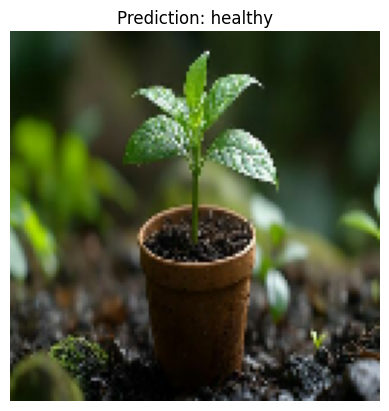

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 74ms/step


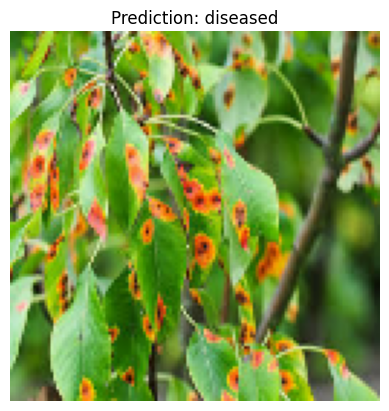

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

for images, labels in test_ds:
    img = images[0]
    img_array = tf.expand_dims(img, 0)
    prediction = model.predict(img_array)
    predicted_class = class_names[np.argmax(prediction)]

    plt.imshow(img.numpy().astype("uint8"))
    plt.title(f"Prediction: {predicted_class}")
    plt.axis("off")
    plt.show()
    
